# Шаг 0: загрузка датасета:

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)

print("загрузка датасета")
df = pd.read_csv("games.csv")


загрузка датасета


# Шаг 1: обзор данных

In [42]:
print(f"Shape: {df.shape}")

Shape: (16719, 16)


In [43]:
display(df.head())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
display(df.tail())

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16718,Winning Post 8 2016,PSV,2016.0,Simulation,Tecmo Koei,0.00,0.00,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
print("===ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ===")
df.info()

===ОБЩАЯ ИНФОРМАЦИЯ О ДАТАСЕТЕ===
<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage:

In [46]:
print("===СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ===")
df.describe()

===СТАТИСТИКА ПО ЧИСЛОВЫМ ПРИЗНАКАМ===


,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16450.000000,16719.000000,16719.000000,16719.000000,16719.000000,16719.000000,8137.000000,8137.000000,7590.000000
mean,2006.487356,0.263330,0.145025,0.077602,0.047332,0.533543,68.967679,26.360821,162.229908
std,5.878995,0.813514,0.503283,0.308818,0.186710,1.547935,13.938165,18.980495,561.282326
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,21.000000,24.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,0.470000,79.000000,36.000000,81.000000
max,2020.000000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [47]:
print("===СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ===")
df.describe(include="string")

===СТАТИСТИКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ===


,Name,Platform,Genre,Publisher,User_Score,Developer,Rating
count,16717,16719,16717,16665,10015,10096,9950
unique,11562,31,12,581,96,1696,8
top,Need for Speed: Most Wanted,PS2,Action,Electronic Arts,tbd,Ubisoft,E
freq,12,2161,3370,1356,2425,204,3991


## Шаг 2: подготовка данных


In [48]:
df = df[['Name',
    'Platform',
    'Year_of_Release',
    'Genre',
    'Publisher',
    #'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales',
    'Global_Sales',
    'Critic_Score',
    'Critic_Count',
    'User_Score',
    'User_Count', 'Developer',
    'Rating'
    ]].copy()
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
df['User_Score'] = pd.to_numeric(df['User_Score'], errors='coerce')
df['Year_of_Release'] = pd.to_numeric(df['Year_of_Release'], errors='coerce')
df['Critic_Count'] = pd.to_numeric(df['Critic_Count'], errors='coerce')
df['User_Count'] = pd.to_numeric(df['User_Count'], errors='coerce')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   Global_Sales     16719 non-null  float64
 6   Critic_Score     8137 non-null   float64
 7   Critic_Count     8137 non-null   float64
 8   User_Score       7590 non-null   float64
 9   User_Count       7590 non-null   float64
 10  Developer        10096 non-null  str    
 11  Rating           9950 non-null   str    
dtypes: float64(6), str(6)
memory usage: 1.5 MB


In [50]:
df = df.rename(columns={'User_Count' : 'User_Rated_Count'}).copy()
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [51]:
print("===КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ===")
print(df.isnull().sum())

===КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ===
Name                   2
Platform               0
Year_of_Release      269
Genre                  2
Publisher             54
Global_Sales           0
Critic_Score        8582
Critic_Count        8582
User_Score          9129
User_Rated_Count    9129
Developer           6623
Rating              6769
dtype: int64


#### Проверяю на дубликаты. Дубликаты по имени не трогаю так как много различных признаков

In [52]:
print("===КОЛИЧЕСТВО ДУБЛИКАТОВ===")
print(df.duplicated().sum())
print("===ДУБЛИКАТЫ ПО ИМЕНИ===")
df.loc[df.duplicated(subset='Name')].head()

===КОЛИЧЕСТВО ДУБЛИКАТОВ===
0
===ДУБЛИКАТЫ ПО ИМЕНИ===


,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Developer,Rating
23,Grand Theft Auto V,X360,2013.0,Action,Take-Two Interactive,16.27,97.0,58.0,8.1,3711.0,Rockstar North,M
35,Call of Duty: Black Ops II,X360,2012.0,Shooter,Activision,13.67,83.0,73.0,4.8,2256.0,Treyarch,M
37,Call of Duty: Modern Warfare 3,PS3,2011.0,Shooter,Activision,13.32,88.0,39.0,3.2,5234.0,"Infinity Ward, Sledgehammer Games",M
41,Call of Duty: Black Ops,PS3,2010.0,Shooter,Activision,12.63,88.0,58.0,6.4,1094.0,Treyarch,M
42,Grand Theft Auto V,PS4,2014.0,Action,Take-Two Interactive,12.61,97.0,66.0,8.3,2899.0,Rockstar North,M


#### Использую ```dropna``` для данных в которых отсутствует Critic_Score или User_Score, так как без этих значений строка не имеет ценности.

In [53]:
df = df.dropna(subset=['Critic_Score', 'User_Score'], how='any').copy()
print(df.isnull().sum())

Name                  0
Platform              0
Year_of_Release     123
Genre                 0
Publisher             4
Global_Sales          0
Critic_Score          0
Critic_Count          0
User_Score            0
User_Rated_Count      0
Developer             4
Rating               70
dtype: int64


#### Также использую ```dropna``` для Publisher и Developer, потому что этих пропусков мало

In [54]:
df = df.dropna(subset=['Publisher', 'Developer'], how='any').copy()
print(df.isnull().sum())
df = df.reset_index(drop=True).copy()

Name                  0
Platform              0
Year_of_Release     120
Genre                 0
Publisher             0
Global_Sales          0
Critic_Score          0
Critic_Count          0
User_Score            0
User_Rated_Count      0
Developer             0
Rating               66
dtype: int64


#### ```Year_of_Release``` заполняю средним, так как распределение равномерное. ```Rating``` заполняю модой

In [55]:
df['Year_of_Release'] = df['Year_of_Release'].fillna(int(df['Year_of_Release'].mean()))
df['Rating'] = df['Rating'].fillna(df['Rating'].mode()[0])
print(df.isnull().sum())

Name                0
Platform            0
Year_of_Release     0
Genre               0
Publisher           0
Global_Sales        0
Critic_Score        0
Critic_Count        0
User_Score          0
User_Rated_Count    0
Developer           0
Rating              0
dtype: int64


# Шаг 3: расширенная статистика

- Дисперсия: насколько значения далеко разбросаны от среднего

- Ассиметрия: показывает симметричность относительно центра
    * skew ≈ 0 → распределение почти симметричное
    * skew > 0 → длинный хвост вправо (есть редкие большие значения)
    * skew < 0 → длинный хвост влево (редкие маленькие значения)

- Эксцесс: показывает "резкойсть" распределения
    * kurt ≈ 3 → нормальное распределение
    * kurt > 3 → острая вершина, длинные хвосты → есть выбросы
    * kurt < 3 → плоская вершина → значения более равномерно распределены

In [56]:
print("===БОЛЕЕ ПОДРОБНАЯ ХАРАКТЕРИСТИКА===")
numeric_stats = df.select_dtypes(include = 'number').agg(['min', 'max', 'mean', 'median', 'var', 'skew', 'kurt'])
display(numeric_stats)

===БОЛЕЕ ПОДРОБНАЯ ХАРАКТЕРИСТИКА===


,Year_of_Release,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count
min,1985.000000,0.010000,13.000000,3.000000,0.500000,4.000000
max,2016.000000,82.530000,98.000000,113.000000,9.600000,10665.000000
mean,2007.473106,0.767719,70.263233,28.793551,7.183721,173.482950
median,2007.000000,0.290000,72.000000,24.000000,7.500000,27.000000
var,17.648285,3.768709,192.435122,367.495472,2.073461,339062.840213
skew,0.108504,16.231429,-0.750024,1.037632,-1.219702,8.703542
kurt,-0.487043,512.497022,0.405415,0.752011,1.613022,104.325710


In [57]:
print("===МОДА===")
num_cols = df.select_dtypes(include='number')
for col in num_cols:
    print(col, "mode:", num_cols[col].mode()[0])

===МОДА===
Year_of_Release mode: 2007.0
Global_Sales mode: 0.02
Critic_Score mode: 80.0
Critic_Count mode: 17.0
User_Score mode: 7.8
User_Rated_Count mode: 6.0


In [58]:
print("\n===ПЕРЦЕНТИЛИ===")
percentiles = [0.05, 0.25, 0.5, 0.75, 0.95]
display(df.select_dtypes(include='number').quantile(percentiles))


===ПЕРЦЕНТИЛИ===


,Year_of_Release,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count
0.05,2001.0,0.03,44.0,6.0,4.3,5.0
0.25,2004.0,0.11,62.0,14.0,6.5,11.0
0.50,2007.0,0.29,72.0,24.0,7.5,27.0
0.75,2011.0,0.75,80.0,39.0,8.2,89.0
0.95,2015.0,2.86,89.0,68.0,8.9,792.8


# Шаг 4: энкодинг

In [59]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.52,82.0,73.0,8.3,709.0,Nintendo,E
2,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,32.77,80.0,73.0,8.0,192.0,Nintendo,E
3,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,29.80,89.0,65.0,8.5,431.0,Nintendo,E
4,Wii Play,Wii,2006.0,Misc,Nintendo,28.92,58.0,41.0,6.6,129.0,Nintendo,E


In [60]:
print("===НОВЫЕ ПРИЗНАКИ===")
print("Age, Score_Product, User_to_Critic_Ratio")

df['Age'] = 2026 - df['Year_of_Release']
df['Score_Product'] = df['Critic_Score']*df['User_Score']
df['User_to_Critic_Ratio'] = df['User_Rated_Count']/df['Critic_Count']

df.head()

===НОВЫЕ ПРИЗНАКИ===
Age, Score_Product, User_to_Critic_Ratio


,Name,Platform,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Developer,Rating,Age,Score_Product,User_to_Critic_Ratio
0,Wii Sports,Wii,2006.0,Sports,Nintendo,82.53,76.0,51.0,8.0,322.0,Nintendo,E,20.0,608.0,6.313725
1,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,35.52,82.0,73.0,8.3,709.0,Nintendo,E,18.0,680.6,9.712329
2,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,32.77,80.0,73.0,8.0,192.0,Nintendo,E,17.0,640.0,2.630137
3,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,29.80,89.0,65.0,8.5,431.0,Nintendo,E,20.0,756.5,6.630769
4,Wii Play,Wii,2006.0,Misc,Nintendo,28.92,58.0,41.0,6.6,129.0,Nintendo,E,20.0,382.8,3.146341


#### OneHotEncoding применил для ```Platform```, так как их немного(<30)

In [61]:
df = pd.get_dummies(df, columns=['Platform'], prefix=['Platform']).copy()
ohe_cols = [col for col in df.columns if col.startswith('Platform_')]
df.head()

,Name,Year_of_Release,Genre,Publisher,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Developer,Rating,Age,Score_Product,User_to_Critic_Ratio,Platform_3DS,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne
0,Wii Sports,2006.0,Sports,Nintendo,82.53,76.0,51.0,8.0,322.0,Nintendo,E,20.0,608.0,6.313725,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
1,Mario Kart Wii,2008.0,Racing,Nintendo,35.52,82.0,73.0,8.3,709.0,Nintendo,E,18.0,680.6,9.712329,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2,Wii Sports Resort,2009.0,Sports,Nintendo,32.77,80.0,73.0,8.0,192.0,Nintendo,E,17.0,640.0,2.630137,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
3,New Super Mario Bros.,2006.0,Platform,Nintendo,29.80,89.0,65.0,8.5,431.0,Nintendo,E,20.0,756.5,6.630769,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,Wii Play,2006.0,Misc,Nintendo,28.92,58.0,41.0,6.6,129.0,Nintendo,E,20.0,382.8,3.146341,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


#### Label encoding применил для ```Rating```, так как  8 разных значений

In [62]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Rating_LE'] = le.fit_transform(df['Rating'])

print("===Label Encoding для Rating ===")
display(df[['Rating', 'Rating_LE']].head())

===Label Encoding для Rating ===


,Rating,Rating_LE
0,E,1
1,E,1
2,E,1
3,E,1
4,E,1


#### Hash ecoding применил для ```Developer``` и ```Publisher```, так как их много, предварительно сгрупировав редкие категории(<10) в other

In [63]:
import category_encoders as ce

dev_counts = df['Developer'].value_counts()
rare_devs = dev_counts[dev_counts < 10].index
df['Developer'] = df['Developer'].replace(rare_devs, 'Other_Devs')

pub_counts = df['Publisher'].value_counts()
rare_pubs = pub_counts[pub_counts < 10].index
df['Publisher'] = df['Publisher'].replace(rare_pubs, 'Other_Pubs')

hash_enc = ce.HashingEncoder(cols=['Developer', 'Publisher'], n_components=32, drop_invariant=False)
df = hash_enc.fit_transform(df)

df.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,Name,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Rating,Age,Score_Product,User_to_Critic_Ratio,Platform_3DS,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Rating_LE
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Sports,2006.0,Sports,82.53,76.0,51.0,8.0,322.0,E,20.0,608.0,6.313725,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Mario Kart Wii,2008.0,Racing,35.52,82.0,73.0,8.3,709.0,E,18.0,680.6,9.712329,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Sports Resort,2009.0,Sports,32.77,80.0,73.0,8.0,192.0,E,17.0,640.0,2.630137,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,New Super Mario Bros.,2006.0,Platform,29.80,89.0,65.0,8.5,431.0,E,20.0,756.5,6.630769,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Play,2006.0,Misc,28.92,58.0,41.0,6.6,129.0,E,20.0,382.8,3.146341,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1


# Шаг 5: визуализация

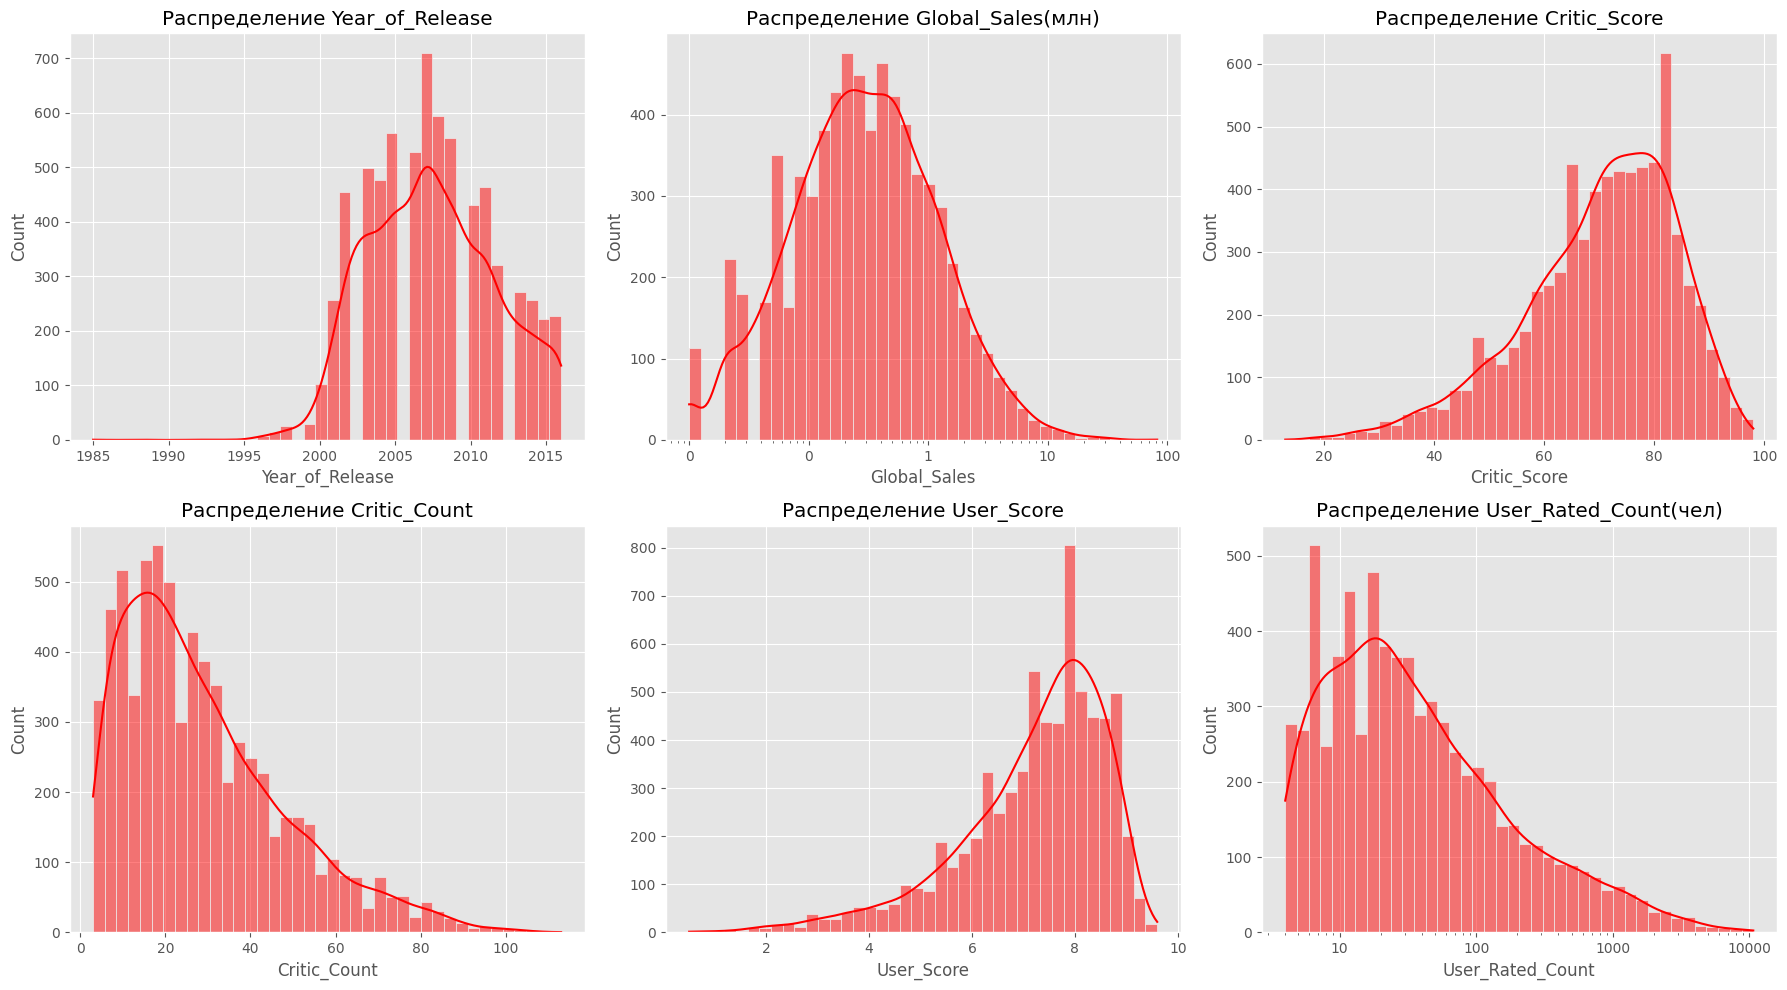

In [64]:
features = [
    'Year_of_Release', 'Global_Sales', 'Critic_Score',
    'Critic_Count', 'User_Score', 'User_Rated_Count',
]

log = {'Global_Sales' : 'млн', 'User_Rated_Count' : 'чел' }

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features):

    if col in log:
        ax = sns.histplot(data=data, x=col, ax=axes[i], kde=True, color='red', bins=40, log_scale=True)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
        title = f'Распределение {col}({log[col]})'
    else:
        data = df
        title = f'Распределение {col}'
        sns.histplot(data=data, x=col, ax=axes[i], kde=True, color='red', bins=40)

    axes[i].set_title(title)

plt.tight_layout()
plt.show()

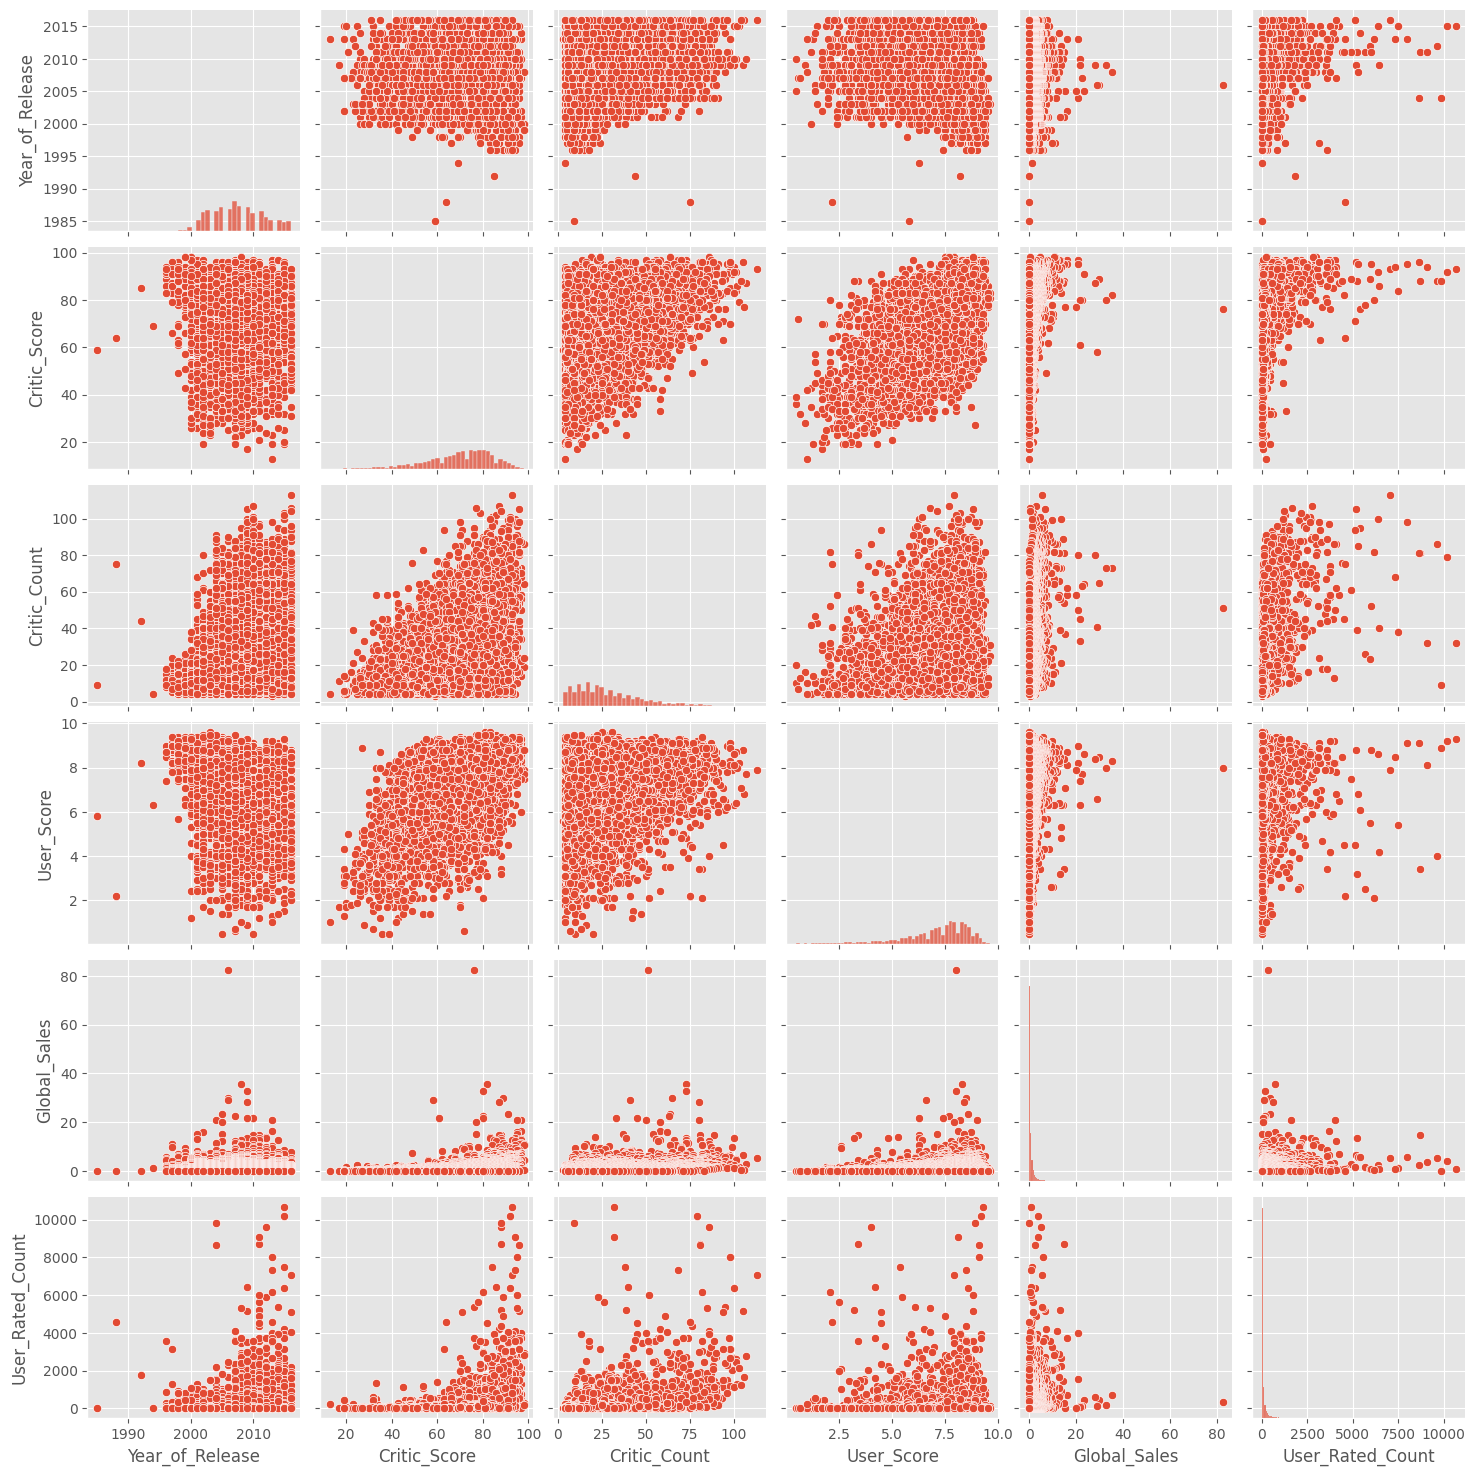

In [65]:
sns.pairplot(df, vars=['Year_of_Release', 'Critic_Score',
                        'Critic_Count', 'User_Score', 'Global_Sales','User_Rated_Count'], )

plt.show()

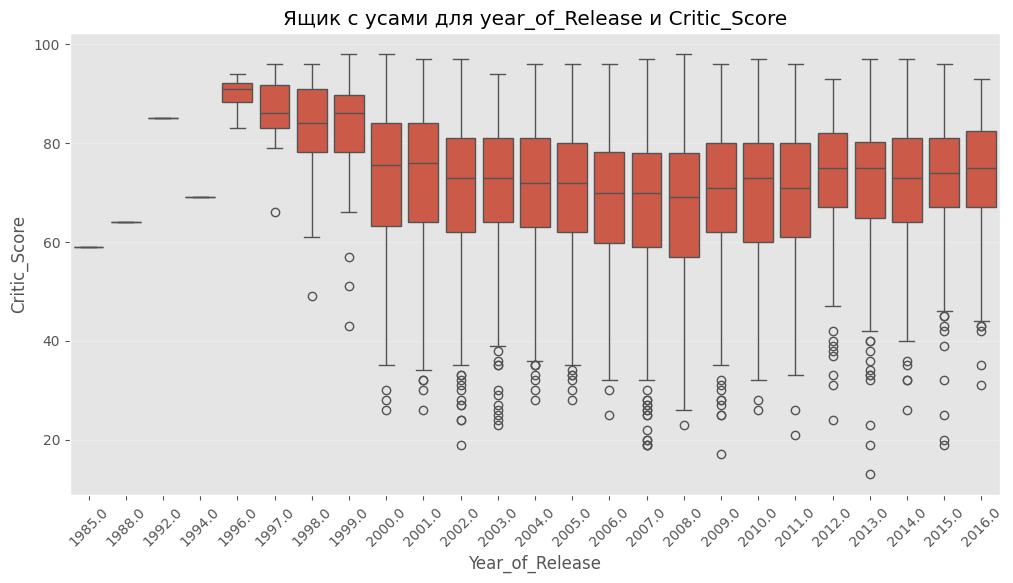

In [66]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df, x='Year_of_Release', y='Critic_Score')

plt.xticks(rotation=45)
plt.title('Ящик с усами для year_of_Release и Critic_Score')
plt.grid(axis='y', alpha=0.3)

plt.show()

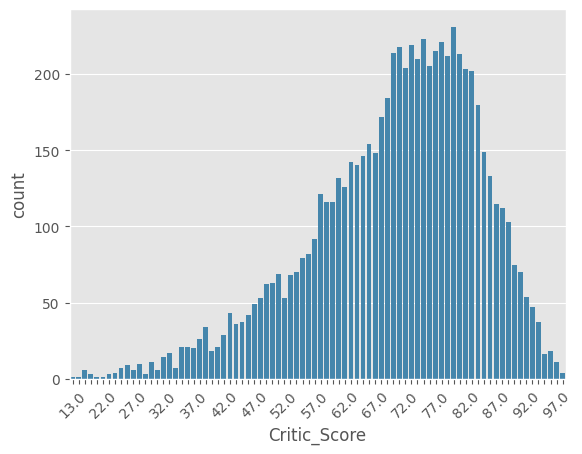

In [67]:
sns.countplot(data=df, x="Critic_Score")
ax = sns.countplot(data=df, x='Critic_Score')
plt.xticks(rotation=45)

for ind, label in enumerate(ax.get_xticklabels()):
    if ind % 5 == 0:
        label.set_visible(True)
    else:
        label.set_visible(False)
plt.show()

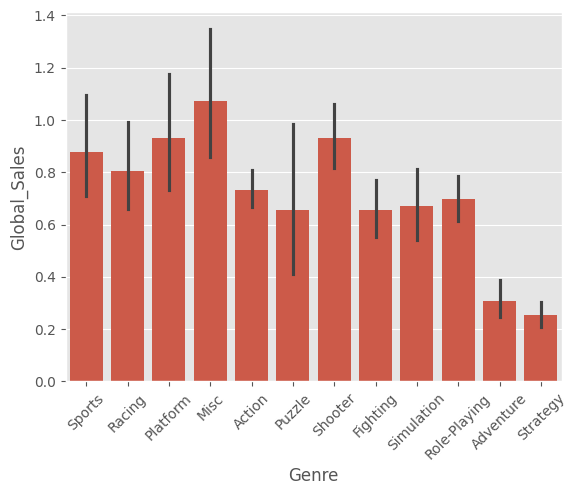

In [70]:
sns.barplot(data=df, x="Genre", y="Global_Sales")
plt.xticks(rotation=45)

plt.show()

In [74]:
df.head()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,col_10,col_11,col_12,col_13,col_14,col_15,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,col_25,col_26,col_27,col_28,col_29,col_30,col_31,Name,Year_of_Release,Genre,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Rated_Count,Rating,Age,Score_Product,User_to_Critic_Ratio,Platform_3DS,Platform_DC,Platform_DS,Platform_GBA,Platform_GC,Platform_PC,Platform_PS,Platform_PS2,Platform_PS3,Platform_PS4,Platform_PSP,Platform_PSV,Platform_Wii,Platform_WiiU,Platform_X360,Platform_XB,Platform_XOne,Rating_LE
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Sports,2006.0,Sports,82.53,76.0,51.0,8.0,322.0,E,20.0,608.0,6.313725,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Mario Kart Wii,2008.0,Racing,35.52,82.0,73.0,8.3,709.0,E,18.0,680.6,9.712329,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Sports Resort,2009.0,Sports,32.77,80.0,73.0,8.0,192.0,E,17.0,640.0,2.630137,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,New Super Mario Bros.,2006.0,Platform,29.80,89.0,65.0,8.5,431.0,E,20.0,756.5,6.630769,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,1
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,Wii Play,2006.0,Misc,28.92,58.0,41.0,6.6,129.0,E,20.0,382.8,3.146341,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,1


#### Наибольшая положительная корреляция наблюдается между оценками критиков и пользователей, а также их производными. Самая сильная отрицательная связь ожидаемо выявлена между годом выпуска и возрастом игры.

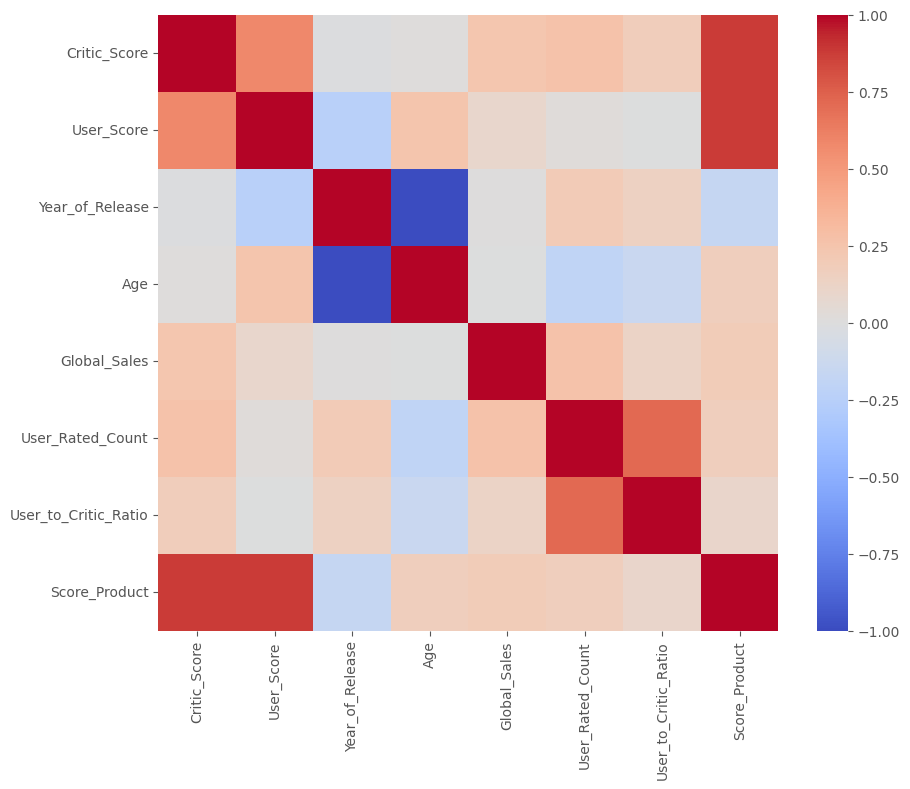

In [76]:
plt.figure(figsize=(10, 8))
cols_to_show = ['Critic_Score', 'User_Score', 'Year_of_Release', 'Age','Global_Sales','User_Rated_Count','User_to_Critic_Ratio','Score_Product']
sns.heatmap(df[cols_to_show].corr(), annot=False, cmap='coolwarm')
plt.show()

# Итоговые выводы
## Что я понял про датасет
- Лидеры рынка: Самой популярной платформой по количеству релизов в данных является PS2 (2161 игра), а самым активным издателем — Electronic Arts.

- Популярные жанры: Жанр «Action» является самым массовым (3370 игр), что подтверждает его доминирующее положение в индустрии.

- Пропуски в оценках: Значительная часть данных (около половины) не имеет оценок критиков или пользователей, что затрудняет анализ качества для старых или нишевых проектов.

- Концентрация продаж: Средние продажи составляют около 0.53 млн копий, однако медиана значительно ниже (0.17 млн), что говорит о сильном смещении в сторону «хитов».

## Гипотезы и наблюдения
- Влияние оценок на продажи: Существует положительная корреляция между Critic_Score и Global_Sales. «Хиты» с оценкой 85+ имеют значительно больше шансов преодолеть порог в 1 млн копий.

- Природа выбросов: Аномалии в продажах (как у Wii Sports) является как бы счастливым случаем успеха

## Цель: Предсказание коммерческого успеха игры на этапе планирования (на основе жанра, издателя и платформы).

## Дополнительные данные: Я бы добавил данные о бюджетах игр, так как высокие продажи не всегда означают прибыльность.

## Какие подсказки брал у AI и что в итоге проверял/дописывал руками
AI: Помог объяснить назначения графиков и синтаксисе pandas

Руками: Самостоятельно форматировал dataframe, делал encoding и основные данные

### Ссылка на датасет: [Video Game Sales with Ratings](https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings)

О данных: Данный датасет содержит информацию о продажах видеоигр, их жанрах, платформах и оценках от критиков и пользователей.